In [6]:
import gymnasium as gym
import numpy as np
import torch
from torch import nn
from dqn import Trainer

GAMMA = 0.99
TRUNC_LENGTH = 2000

In [7]:
# creating the modified environment
env = gym.make('MountainCar-v0', max_episode_steps=TRUNC_LENGTH)

In [8]:
# creating the trainer -
dqn_trainer = Trainer(
    env=env,
    gamma=GAMMA,
    seed=0,
    use_wandb=True,
    wandb_project="RL_PA2",
    wandb_run_name="q2_test_0",
    trunc_length=TRUNC_LENGTH
)

In [9]:
train_rewards = dqn_trainer.train(num_episodes=1500)

buffer_size,▁▂▂▂▄▅▅▆▆▆▇█████████████████████████████
episode,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▆▆▆▇▇▇▇█
episode_length,█▅▂▃▂▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁
episode_mean_loss,█▃▂▂▂▁▁▁▁▁▁▁▁▁▂▂▃▂▂▃▄▃▃▂▂▃▂▂▂▂▂▂▁▁▃▃▃▂▂▂
episode_return,▁▁▆▁▅▇▇█▇▇▇▇███████████████████████▇████
episode_steps,▆▄▁▇▆▇▇▂▆▄▄▅▅█▃▆▂▁▄▂▃▂▃▂▂▂▁▂▂▁▁▁▂▁▁▁▁▁▁▁
epsilon,█████████▇▇▇▇▇▇▇▇▇▇▇▇▆▆▆▆▅▄▄▄▃▂▂▂▁▁▁▁▁▁▁
loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
target_updates,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
total_env_steps,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇███
buffer_size,125000


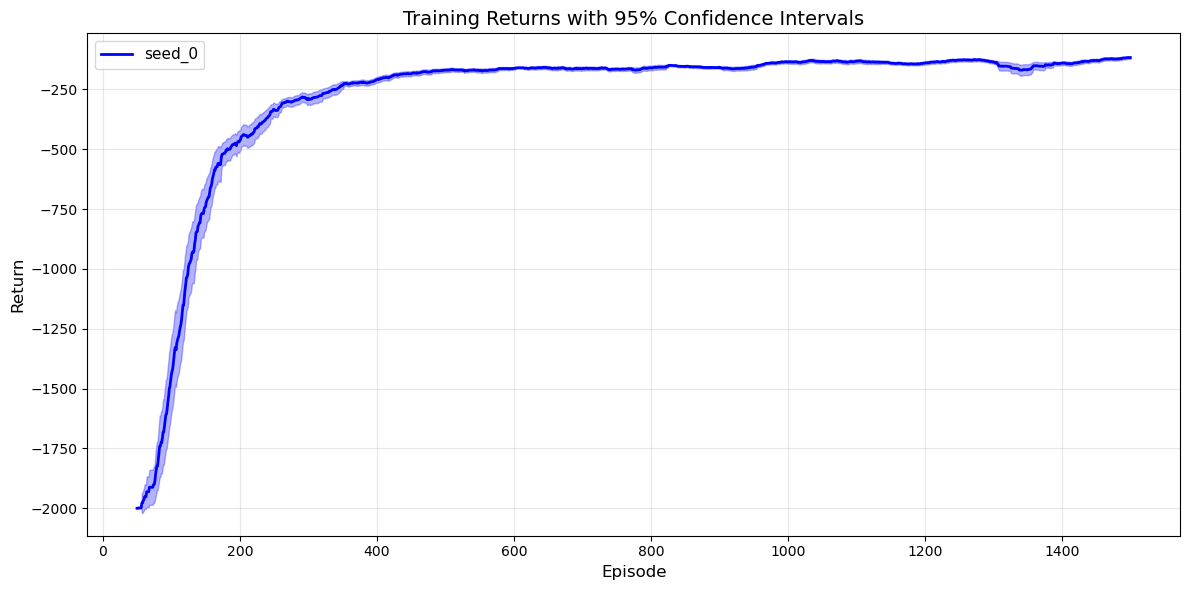

Mean return: -300.74
Std return: 425.34
Max return: -86.00
Min return: -2000.00


In [11]:
import matplotlib.pyplot as plt
from scipy import stats

# Compute rolling mean and confidence intervals
window_size = 50
train_rewards_array = np.array(train_rewards)
rolling_mean = np.convolve(train_rewards_array, np.ones(window_size)/window_size, mode='valid')
rolling_std = np.array([np.std(train_rewards_array[i:i+window_size]) for i in range(len(train_rewards_array) - window_size + 1)])

# Compute 95% confidence intervals
confidence_level = 0.95
df = window_size - 1
t_val = stats.t.ppf((1 + confidence_level) / 2, df)
rolling_ci = t_val * (rolling_std / np.sqrt(window_size))

# Create plot
episodes = np.arange(len(rolling_mean)) + window_size
plt.figure(figsize=(12, 6))
plt.plot(episodes, rolling_mean, label=f'seed_{0}', linewidth=2, color='blue')
plt.fill_between(episodes, rolling_mean - rolling_ci, rolling_mean + rolling_ci, alpha=0.3, color='blue')
plt.xlabel('Episode', fontsize=12)
plt.ylabel('Return', fontsize=12)
plt.title('Training Returns with 95% Confidence Intervals', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean return: {np.mean(train_rewards_array):.2f}")
print(f"Std return: {np.std(train_rewards_array):.2f}")
print(f"Max return: {np.max(train_rewards_array):.2f}")
print(f"Min return: {np.min(train_rewards_array):.2f}")